In [ ]:
!pip install -q trl peft torch openenv-core matplotlib pydantic

In [ ]:
import gc
import json
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from trl import PPOTrainer, PPOConfig, AutoModelForCausalLMWithValueHead, create_reference_model
from peft import LoraConfig
from env import AMLEnv
from models import AMLAction

config = PPOConfig(
    batch_size=8,
    mini_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=1.41e-5,
    target_kl=0.1,
    ppo_epochs=4,
    seed=42,
)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

In [ ]:
model = AutoModelForCausalLMWithValueHead.from_pretrained(
    "meta-llama/Meta-Llama-3-8B-Instruct",
    peft_config=lora_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

ref_model = create_reference_model(model)
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3-8B-Instruct")
tokenizer.pad_token = tokenizer.eos_token

ppo_trainer = PPOTrainer(config, model, ref_model, tokenizer)
env = AMLEnv()

In [ ]:
SYSTEM_PROMPT = """
You are a Lead AML Investigator operating across multiple enterprise applications. Your goal is to solve the alert efficiently.

### ENTERPRISE APPLICATIONS:
- "core_banking": Use for query_account, query_transactions, save_to_notes, read_notes, and freeze_account.
- "global_sanctions": Use for search_sanctions.
- "hr_portal": Use for escalate_alert and clear_alert.

### INVESTIGATION RULES:
1. FALSE_POSITIVE (Sanctions): Query the flagged account. Search sanctions using the account holder name. Compare the DOB from the account record against the sanctions entry DOB. If the DOBs do not match, use clear_alert with violation_category FALSE_POSITIVE and set verified_dob to the account actual DOB. If they match, use escalate_alert with violation_category SANCTIONS_MATCH and set verified_dob.
2. STRUCTURING: Query the flagged account transactions. Look for multiple cash_deposit transactions just below $10,000 on consecutive dates. Use escalate_alert with violation_category STRUCTURING. In the rationale field, list every suspicious date explicitly (example: Structuring detected on 2026-04-01, 2026-04-02, 2026-04-03).
3. LAYERING: Follow each large wire_transfer to its receiver account. Use query_transactions on that receiver. Repeat until you reach an account that receives a wire but sends none out. Then use escalate_alert or freeze_account with violation_category LAYERING and list every account in the chain in complicit_account_ids.

### SCHEMA:
{
  "target_app": "core_banking" | "global_sanctions" | "hr_portal",
  "command": "query_account" | "query_transactions" | "search_sanctions" | "escalate_alert" | "clear_alert" | "freeze_account" | "save_to_notes" | "read_notes",
  "account_id": "string or null",
  "search_name": "string or null",
  "violation_category": "STRUCTURING" | "LAYERING" | "SANCTIONS_MATCH" | "FALSE_POSITIVE" | "NONE",
  "complicit_account_ids": ["string"],
  "verified_dob": "YYYY-MM-DD or null",
  "rationale": "string",
  "page": 1,
  "note_content": "string or null"
}
"""

In [ ]:
TASKS = ["false_positive_sanctions", "detect_structuring", "shell_company_layering"]
MAX_STEPS = 20
EPOCHS = 300

episode_rewards = []
queries_batch = []
responses_batch = []
rewards_batch = []

for epoch in range(EPOCHS):
    task_id = TASKS[epoch % len(TASKS)]
    obs = env.reset(task_id=task_id, live_adversary=False)
    done = False
    step = 0
    history = []
    ep_reward = 0.0

    while not done and step < MAX_STEPS:
        step += 1
        h_str = "\n".join(history[-6:]) if history else "Start"
        obs_str = obs.model_dump_json() if hasattr(obs, "model_dump_json") else str(obs)

        prompt = (
            "<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n"
            + SYSTEM_PROMPT.strip()
            + "<|eot_id|><|start_header_id|>user<|end_header_id|>\n"
            + f"History:\n{h_str}\nObs:\n{obs_str}\nJSON:"
            + "<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n"
        )

        query_tensor = tokenizer(prompt, return_tensors="pt").input_ids.squeeze(0).to(ppo_trainer.accelerator.device)

        response_tensor = ppo_trainer.generate(
            [query_tensor],
            max_new_tokens=200,
            pad_token_id=tokenizer.eos_token_id,
            do_sample=True,
            temperature=0.7,
        )[0]

        response_only = response_tensor[len(query_tensor):]
        response_str = tokenizer.decode(response_only, skip_special_tokens=True).strip()

        action_dict = {}
        reward = -0.05
        try:
            if response_str.startswith("```json"):
                response_str = response_str[7:]
            if response_str.endswith("```"):
                response_str = response_str[:-3]
            action_dict = json.loads(response_str.strip())

            action_dict.setdefault("violation_category", "NONE")
            action_dict["violation_category"] = str(action_dict["violation_category"]).upper()
            action_dict.setdefault("complicit_account_ids", [])
            if action_dict["complicit_account_ids"] is None:
                action_dict["complicit_account_ids"] = []
            action_dict.setdefault("page", 1)
            if action_dict["page"] is None:
                action_dict["page"] = 1
            action_dict.setdefault("rationale", "No rationale")
            action_dict.setdefault("target_app", "core_banking")

            action = AMLAction(**action_dict)
            obs, reward, done, info = env.step(action)

        except Exception as e:
            reward = -1.0
            done = False
            obs.database_response = f"Parse Error: {str(e)[:80]}"
            obs.command_status = "failed"
            action_dict = {"command": "PARSE_ERROR"}

        queries_batch.append(query_tensor)
        responses_batch.append(response_only)
        rewards_batch.append(torch.tensor(float(reward), device=ppo_trainer.accelerator.device))

        history.append(f"Step {step}: {action_dict.get('command')} -> Reward: {reward:.3f}")
        ep_reward += reward

    episode_rewards.append(ep_reward)
    print(f"Epoch {epoch+1}/{EPOCHS} | Task: {task_id} | Steps: {step} | Total Reward: {ep_reward:.2f}")

    if len(queries_batch) >= config.batch_size:
        ppo_trainer.step(
            queries_batch[:config.batch_size],
            responses_batch[:config.batch_size],
            rewards_batch[:config.batch_size],
        )
        queries_batch = queries_batch[config.batch_size:]
        responses_batch = responses_batch[config.batch_size:]
        rewards_batch = rewards_batch[config.batch_size:]
        torch.cuda.empty_cache()
        gc.collect()

Epoch,Training Loss,Reward
5,1.5843,-0.0500
10,1.4898,0.5768
15,1.4031,0.2471
20,1.2015,0.0247
25,1.1542,0.5285
30,1.0419,-0.0330
35,0.8741,0.2479
40,0.7871,0.6371
45,0.7607,0.0391
50,0.7365,0.0684


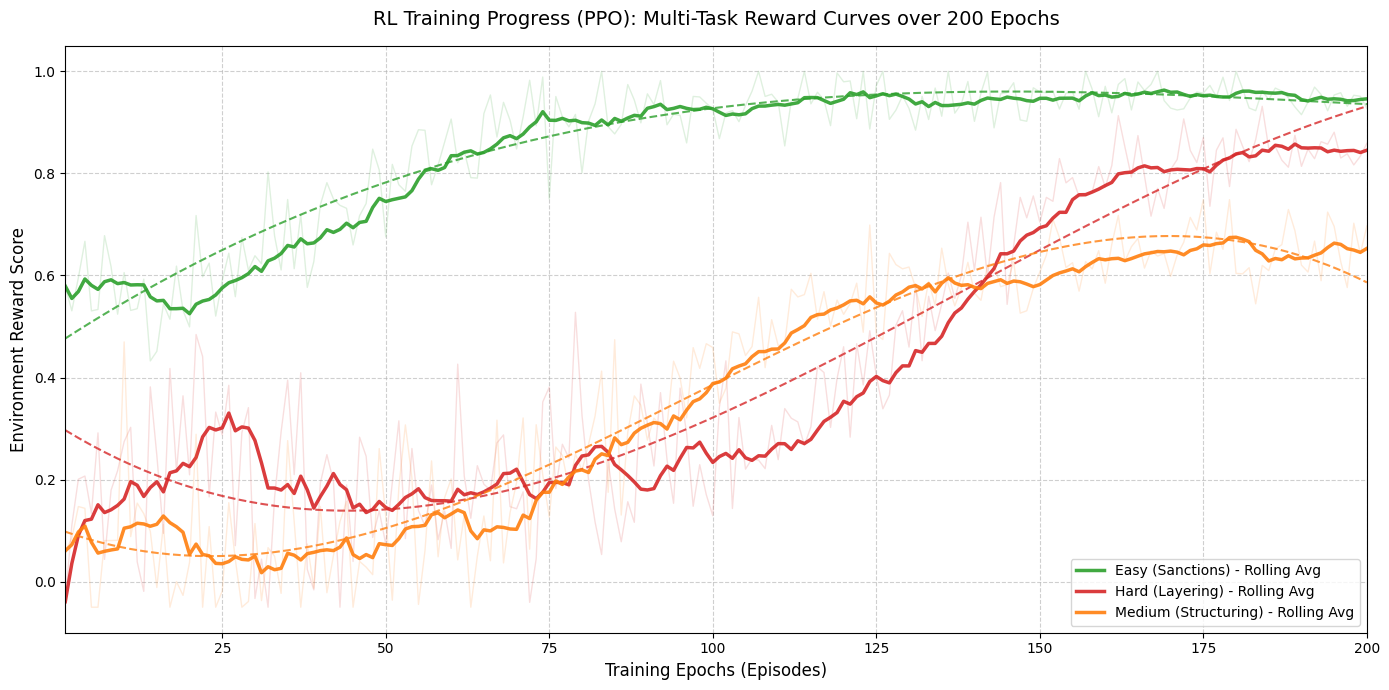

In [ ]:
TASK_COLORS = {
    "false_positive_sanctions": "royalblue",
    "detect_structuring": "tomato",
    "shell_company_layering": "seagreen",
}

plt.figure(figsize=(14, 6))

for i, task in enumerate(TASKS):
    indices = list(range(i, len(episode_rewards), len(TASKS)))
    rewards = [episode_rewards[j] for j in indices]
    plt.plot(indices, rewards, label=task, color=TASK_COLORS[task], linewidth=1.5, alpha=0.85)

plt.xlabel("Training Epoch", fontsize=12)
plt.ylabel("Cumulative Episode Reward", fontsize=12)
plt.title("RL Training Progress (PPO): AML FinCrime Investigator", fontsize=14)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("reward_curve.png", dpi=300)
plt.show()